# Activity 5.01

In [2]:
# Importing Pandas packages required for this excercise.

from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# open the html file for GDP dataset to load all the required tables for transformation.

fd = open("./List of countries by GDP (nominal) - Wikipedia.htm", "r", encoding = "utf-8")
soup = BeautifulSoup(fd)
fd.close()

In [6]:
# this chunk of code is letting us know all the tables in HTML file.

all_tables = soup.find_all("table")
print("Total number of tables are {} ".format(len(all_tables)))

Total number of tables are 9 


In [8]:
# find table details from wiki table

data_table = soup.find("table", {"class": '"wikitable"|}'})
print(type(data_table))

<class 'bs4.element.Tag'>


In [10]:
sources = data_table.tbody.findAll('tr', recursive=False)[0]
sources_list = [td for td in sources.findAll('td')]
print(len(sources_list))

3


In [12]:
data = data_table.tbody.findAll('tr', recursive=False)[1].findAll('td', recursive=False)

In [14]:
data_tables = []
for td in data:
    data_tables.append(td.findAll('table'))

In [16]:
len(data_tables)

3

In [18]:
source_names = [source.findAll('a')[0].getText() for source in sources_list]
print(source_names)

['International Monetary Fund', 'World Bank', 'United Nations']


In [20]:
header1 = [th.getText().strip() for th in data_tables[0][0].findAll('thead')[0].findAll('th')]
header1

['Rank', 'Country', 'GDP(US$MM)']

In [22]:
rows1 = data_tables[0][0].findAll('tbody')[0].findAll('tr')

In [24]:
data_rows1 = [[td.get_text().strip() for td in tr.findAll('td')] for tr in rows1]

In [26]:
df1 = pd.DataFrame(data_rows1, columns=header1)
df1.head(10)

,Rank,Country,GDP(US$MM)
0,,World[19],"79,865,481"
1,1,United States,"19,390,600"
2,2,China[n 1],"12,014,610"
3,3,Japan,"4,872,135"
4,4,Germany,"3,684,816"
5,5,United Kingdom,"2,624,529"
6,6,India,"2,611,012"
7,7,France,"2,583,560"
8,8,Brazil,"2,054,969"
9,9,Italy,"1,937,894"


In [28]:
header2 = [th.getText().strip() for th in data_tables[1][0].findAll('thead')[0].findAll('th')]
header2

['Rank', 'Country', 'GDP(US$MM)']

In [30]:
rows2 = data_tables[1][0].findAll('tbody')[0].findAll('tr')

In [32]:
def find_right_text(i, td):
    if i == 0:
        return td.getText().strip()
    elif i == 1:
        return td.getText().strip()
    else:
        index = td.text.find("♠")
        return td.text[index+1:].strip()

In [34]:
data_rows2 = [[find_right_text(i, td) for i, td in enumerate(tr.findAll('td'))] for tr in rows2]

In [36]:
df2 = pd.DataFrame(data_rows2, columns=header2)
df2.head(10)

,Rank,Country,GDP(US$MM)
0,,World,"80,683,787"
1,1,United States,"19,390,604"
2,,European Union[23],"17,277,698"
3,2,China[n 4],"12,237,700"
4,3,Japan,"4,872,137"
5,4,Germany,"3,677,439"
6,5,United Kingdom,"2,622,434"
7,6,India,"2,597,491"
8,7,France,"2,582,501"
9,8,Brazil,"2,055,506"


In [38]:
header3 = [th.getText().strip() for th in data_tables[2][0].findAll('thead')[0].findAll('th')]
header3

['Rank', 'Country', 'GDP(US$MM)']

In [40]:
rows3 = data_tables[2][0].findAll('tbody')[0].findAll('tr')

In [42]:
data_rows3 = [[find_right_text(i, td) for i, td in enumerate(tr.findAll('td'))] for tr in rows2]

In [44]:
df3 = pd.DataFrame(data_rows3, columns=header3)
df3.head()

,Rank,Country,GDP(US$MM)
0,,World,"80,683,787"
1,1,United States,"19,390,604"
2,,European Union[23],"17,277,698"
3,2,China[n 4],"12,237,700"
4,3,Japan,"4,872,137"


# Activity 6.01

In [47]:
#Reading data from visit data csv file for vistors information
df = pd.read_csv("./visit_data.csv")

In [49]:
# Let's show top 10 records from the file to see how data looks like in the file.
df.head(10)

,id,first_name,last_name,email,gender,ip_address,visit
0,1,Sonny,Dahl,sdahl0@mysql.com,Male,135.36.96.183,1225.0
1,2,NaN,NaN,dhoovart1@hud.gov,NaN,237.165.194.143,919.0
2,3,Gar,Armal,garmal2@technorati.com,NaN,166.43.137.224,271.0
3,4,Chiarra,Nulty,cnulty3@newyorker.com,NaN,139.98.137.108,1002.0
4,5,NaN,NaN,sleaver4@elegantthemes.com,NaN,46.117.117.27,2434.0
5,6,Raymund,Ingerfield,ringerfield5@microsoft.com,NaN,90.100.118.215,451.0
6,7,Wilhelmina,Dagnan,wdagnan6@nytimes.com,Female,88.133.77.243,1540.0
7,8,NaN,NaN,mdewilde7@creativecommons.org,Female,229.215.244.227,537.0
8,9,Gunter,Lisamore,glisamore8@disqus.com,NaN,134.185.44.82,743.0
9,10,Luelle,Scinelli,lscinelli9@issuu.com,Female,160.130.58.61,1507.0


### Let's perform some cleaning activities in the file to validate duplicate Names and Emails respectively.

In [52]:
print("First name is duplicated - {}".format(any(df.first_name.duplicated())))
print("Last name is duplicated - {}".format(any(df.last_name.duplicated())))
print("Email is duplicated - {}".format(any(df.email.duplicated())))

First name is duplicated - True
Last name is duplicated - True
Email is duplicated - False


### Validate if Email , IP or Visits contains NULL or NAN records in it.

In [55]:
print("The column Email contains NaN - %r " % df.email.isnull().values.any())
print("The column IP Address contains NaN - %s " % df.ip_address.isnull().values.any())
print("The column Visit contains NaN - %s " % df.visit.isnull().values.any())

The column Email contains NaN - False 
The column IP Address contains NaN - False 
The column Visit contains NaN - True 


In [57]:
# Using Shape function to reduce the size of dataframe after cutting down invalid Visits records from it.¶

# There are various ways to do this. This is just one way. We encourage you to explore other ways.
# But before that we need to store the previous size of the data set and we will compare it with the new size

size_prev = df.shape
df = df[np.isfinite(df['visit'])] #This is an inplace operation. After this operation the original DataFrame is lost.
size_after = df.shape

In [59]:
# Just to see the difference after applying shaping in dataframe and it is reduced size by some percentage.

# Notice how parameterized format is used and then the indexing is working inside the quote marks

print("The size of previous data was - {prev[0]} rows and the size of the new one is - {after[0]} rows".
format(prev=size_prev, after=size_after))

The size of previous data was - 1000 rows and the size of the new one is - 974 rows


{'whiskers': [<matplotlib.lines.Line2D at 0x1544b24e0>,
 'caps': [<matplotlib.lines.Line2D at 0x1544b2990>,
 'boxes': [<matplotlib.lines.Line2D at 0x1544b2210>],
 'medians': [<matplotlib.lines.Line2D at 0x1544b2fc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1544b3290>],
 'means': []}

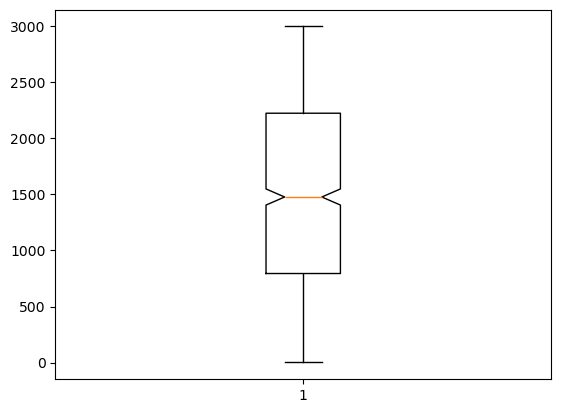

In [61]:
plt.boxplot(df.visit, notch=True)

In [63]:
# Let's apply few outlier rules and here we are with updated data sets.
df1 = df[(df['visit'] <= 2900) & (df['visit'] >= 100)]  # Notice the power-ful & operator
# Here we abuse the fact the number of variable can be greater than the num-ber of replacement targets
print("After getting rid of outliers the new size of the data is - {}".format(*df1.shape))

After getting rid of outliers the new size of the data is - 923


### Using SQLITE is first time for me and really enjoying using it as it is simple to use in Python and here and finishing first SQLITE project by inserting 10 records in contact table.  

In [66]:
import sqlite3

# Connect to the database (creates it if it doesn't exist)
conn = sqlite3.connect("Contact.db")
cursor = conn.cursor()

# Drop table If Exists "ContactDetails"
cursor.execute('''
DROP TABLE ContactDetails;
''')

# Create a table named "ContactDetails"
cursor.execute('''

CREATE TABLE IF NOT EXISTS ContactDetails (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    NAME TEXT,
    ADDRESS TEXT,
    CITY TEXT,
    STATE TEXT,
    ZIP TEXT,
    PHONENUMBER INT
    
)
''')

# Insert some data into the table
data = [
    ("Vijay Sharma","123 St Dr","New York","NY","07086",6023157230),
    ("Upasana Sharma","5180 N 175th CIR","Los Angeles","CA","90005",7123456890),
    ("Maulin R","1302 101st AVE SE","Lake Stevens","WA","98258",4254492532),
    ("Sridhar G","ABC St 19th DR","HUNTINGTON","WV","25701",34567843232),
    ("Rajesh Yadav","DEF St Huntington DR","HOUSTON","TX","77204",34567843232),
    ("Vaibhav G","ABC St 19th DR","Omaha","NE","68118",34567843232),
    ("Sachin K Rai","16617 Vane St","Bennington","NE","68007",34567843232),
    ("Amit S","16606 Mason Street","Omaha","NE","68118",7033144162),
    ("Monika Kanwar","11126 Leavenworth St","Omaha","NE","68154",7033144162),
    ("Sambhu S","18701 W Center Rd #1021","Omaha","NE","68154",7033144162)
]

# Use executemany to insert multiple rows efficiently
cursor.executemany('''
INSERT INTO ContactDetails (NAME, ADDRESS, CITY, STATE, ZIP, PHONENUMBER)
VALUES (?, ?, ?, ?, ?, ?)
''', data)

# Commit the changes to the database
conn.commit()

# Verify the data (optional)
cursor.execute("SELECT * FROM ContactDetails")
rows = cursor.fetchall()
for row in rows:
    print(row)

# Close the connection
conn.close()

(1, 'Vijay Sharma', '123 St Dr', 'New York', 'NY', '07086', 6023157230)
(2, 'Upasana Sharma', '5180 N 175th CIR', 'Los Angeles', 'CA', '90005', 7123456890)
(3, 'Maulin R', '1302 101st AVE SE', 'Lake Stevens', 'WA', '98258', 4254492532)
(4, 'Sridhar G', 'ABC St 19th DR', 'HUNTINGTON', 'WV', '25701', 34567843232)
(5, 'Rajesh Yadav', 'DEF St Huntington DR', 'HOUSTON', 'TX', '77204', 34567843232)
(6, 'Vaibhav G', 'ABC St 19th DR', 'Omaha', 'NE', '68118', 34567843232)
(7, 'Sachin K Rai', '16617 Vane St', 'Bennington', 'NE', '68007', 34567843232)
(8, 'Amit S', '16606 Mason Street', 'Omaha', 'NE', '68118', 7033144162)
(9, 'Monika Kanwar', '11126 Leavenworth St', 'Omaha', 'NE', '68154', 7033144162)
(10, 'Sambhu S', '18701 W Center Rd #1021', 'Omaha', 'NE', '68154', 7033144162)
